In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Метрики качества модели регрессии

Метрики в машинном обучении нужны для того, чтобы оценивать качество работы модели и понимать насколько хорошо она запомнила закономерности в данных по обучающей выборке.  

В этом ноутбуке мы рассматриваем метрики для задачи регрессии - предсказания непрерывной целевой переменной. В такой задаче желательно, чтобы модель предсказывала числа как можно ближе к истинным, чтобы отклонения реального значения и прогноза модели были минимальными.

Для подсчета разных метрик регрессии сгенерируем данные в `sklearn`.

## Получение данных

Будем работать с набором данных для задачи регрессии из одного признака, с небольшим шумом, сгенерированным в `sklearn`.

In [2]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_targets=1,
    noise=10,
    random_state=42
)

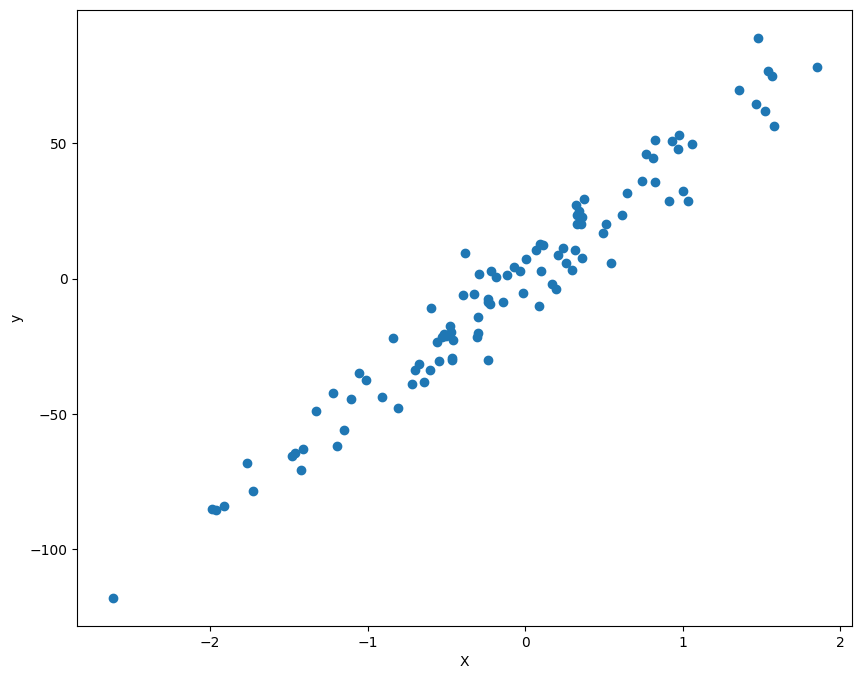

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y');

## Обучение модели

Разобьем выборку на две: обучающую и тестовую.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80, 1), (80,), (20, 1), (20,))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)

Теперь сделаем предсказания на тестовой выборке, чтобы понять, насколько хорошо модель научилась предсказывать переменную у.

In [ ]:
pred = model.predict(X_test)

In [ ]:
df = pd.DataFrame(X_test, columns=['X'])
df['y_true'] = y_test
df['y_pred'] = pred
df

,X,y_true,y_pred
0,-1.328186,-48.949080,-65.268405
1,1.477894,89.033145,66.914877
2,0.812526,44.409196,41.090637
3,-0.392108,-5.911314,-13.846880
4,-0.234153,-7.624431,-8.942499
5,-0.291694,1.747639,-14.145684
6,-0.465730,-29.365934,-22.926098
7,-1.763040,-68.326754,-79.838305
8,0.821903,35.765733,41.090637
9,0.931280,50.779929,41.969138


## Проверка точности модели

### MAE

Найдем абсолютные значения отклонений предсказнных значений от истинных:


In [ ]:
df['abs'] = abs(df['y_pred'] - df['y_true'])
df

,X,y_true,y_pred,abs
0,-1.328186,-48.949080,-65.268405,16.319325
1,1.477894,89.033145,66.914877,22.118268
2,0.812526,44.409196,41.090637,3.318559
3,-0.392108,-5.911314,-13.846880,7.935566
4,-0.234153,-7.624431,-8.942499,1.318068
5,-0.291694,1.747639,-14.145684,15.893323
6,-0.465730,-29.365934,-22.926098,6.439836
7,-1.763040,-68.326754,-79.838305,11.511550
8,0.821903,35.765733,41.090637,5.324903
9,0.931280,50.779929,41.969138,8.810792


Найдем среднее отклонение по модулю для всей выборки:

In [ ]:
df['abs'].mean()

8.674020556387939

Получается мы в среднем ошибаемся на 8.7 единиц по всей выборке. Это мы подсчитали метрику под названием MAE (mean absolute error, средне-абсолютная ошибка).

$$MAE = \frac{1}{n}\sum_i^n{|y_{true} - y_{pred}|}$$

Она реализована в библиотеки `sklearn` в модуле `metrics`:


In [ ]:
from sklearn.metrics import mean_absolute_error

Можем не вручную считать MAE, а с помощью функции `mean_absolute_error`:

In [ ]:
mean_absolute_error(df['y_true'], df['y_pred'])

8.674020556387939

Получается такое же значения метрики, как мы получали при ручном подсчете.   
Чем метрика MAE ближе к нулю, тем лучше, в этом случае мы при предсказании угадываем все истинные значения.

### MSE

Другой вариант подсчета ошибки модели - возводить отклонения в квадрат, а затем так же искать среднее по выборке:

In [ ]:
df['squared'] = (df['y_pred'] - df['y_true']) ** 2
df

,X,y_true,y_pred,abs,squared
0,-1.328186,-48.949080,-65.268405,16.319325,266.320377
1,1.477894,89.033145,66.914877,22.118268,489.217788
2,0.812526,44.409196,41.090637,3.318559,11.012835
3,-0.392108,-5.911314,-13.846880,7.935566,62.973204
4,-0.234153,-7.624431,-8.942499,1.318068,1.737303
5,-0.291694,1.747639,-14.145684,15.893323,252.597730
6,-0.465730,-29.365934,-22.926098,6.439836,41.471489
7,-1.763040,-68.326754,-79.838305,11.511550,132.515794
8,0.821903,35.765733,41.090637,5.324903,28.354595
9,0.931280,50.779929,41.969138,8.810792,77.630052


Найдем среднее отклонение в квадрате для всей выборки:

In [ ]:
df['squared'].mean()

108.14198878074414

Получается мы в среднем ошибаемся на 108 квадратичных единиц по всей выборке. Эта метрика называется MSE (mean squared error, средне-квадратичная ошибка).

$$MSE = \frac{1}{n}\sum_i^n{(y_{true} - y_{pred})^2}$$

Она тоже реализована в библиотеки `sklearn` в модуле `metrics`:


In [ ]:
from sklearn.metrics import mean_squared_error

Посчитаем MSE с помощью функции `mean_squared_error`:

In [ ]:
mean_squared_error(df['y_true'], df['y_pred'])

108.14198878074414

И снова наши значения совпали. Чем метрика MSE ближе к нулю, тем лучше.

MSE часто используется как функция потерь, но когда мы хотим понять, насколько модель ошибается, метрика MSE может вносить неясность из-за квадратов единиц измерения выходного признака.

### RMSE

Отклонения считали в квадрате, поэтому если наша стоимость изменяется в рублях, то mse дает цифру рубли в квадрате, что усложняет интерпретацию результата. Это легко исправить взятием корня квадратного из значения MSE - это и есть новая метрика RMSE.

Для подсчета этой метрики можно усреднить квадратичные отклонения (то есть получить MSE), а затем взять корень квадратный:

In [ ]:
np.sqrt(df['squared'].mean())

10.399134039945064

Теперь очевидно, что в среднем ошибаемся на 10.4 единиц по всей выборке, либо в большую, либо в меньшую сторону. Эта метрика RMSE (root mean squared error).

$$RMSE = \sqrt{\frac{1}{n}\sum_i^n{(y_{true} - y_{pred})^2}}$$

Она не реализована в библиотеки `sklearn`, но как мы поняли, метрика - это MSE  с корнем:


In [ ]:
np.sqrt(mean_squared_error(df['y_true'], df['y_pred']))

10.399134039945064

Значения идентичны.
И так же, как предыдущие метрики, чем метрика RMSE ближе к нулю, тем лучше.

### Коэффициент $R^2$ детерминации

Именно эта метрика используется в sklearn по умолчанию для задачи регрессии. В нашем случае она принимает значение:

In [ ]:
model.score(X_test, y_test)

0.9350489024280596

Давайте остановимся на ней поподробнее.

Первые три метрики, которые мы рассмотрели, имеют идеальное значение 0, к которому нужно стремиться, но эти метрики не имеют пороговых значений, выше которых мы считаем, что модель ужасная.

К примеру, если наша целевая переменная изменяется от 0 до 10:

In [ ]:
y_true = [0, 3, 6, 2, 9]

Наша модель может предсказать:

In [ ]:
y_pred = [1, 5, 9, 6, 14]

Соединим предсказания и истинные значения в одном датафрейме и найдем разницу между ними:

In [ ]:
df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
})

df['difference'] = df['y_pred'] - df['y_true']
df

,y_true,y_pred,difference
0,0,1,1
1,3,5,2
2,6,9,3
3,2,6,4
4,9,14,5


И мы получим следующее значение средне-квадратичной ошибки:

In [ ]:
mean_squared_error(y_true, y_pred)

11.0

А если наша целевая переменная изменяется от 0 до 10000:

In [ ]:
y_true = [0, 300, 6000, 2000, 9900]

Наша модель может предсказать:

In [ ]:
y_pred = [1, 302, 6003, 2004, 9905]

Соединим предсказания и истину вместе и найдем разницу между ними:

In [ ]:
df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
})

df['difference'] = df['y_pred'] - df['y_true']
df

,y_true,y_pred,difference
0,0,1,1
1,300,302,2
2,6000,6003,3
3,2000,2004,4
4,9900,9905,5


И мы получим следующее значение средне-квадратичной ошибки:

In [ ]:
mean_squared_error(y_true, y_pred)

11.0

MSE получились одинаковыми, потому что одинаковые разницы в предсказаниях, но вторая модель очевидно делает меньше ошибок, чем первая, значит она более качественная, хотя значения метрики MSE абсолютно одинаковые.

MSE не позволяет сама по себе сделать вывод о том, как хорошо модель решает задачу. Вот как в нашем примере, если целевая переменная принимает значения от 0 до 10, а MSE равняется 11, это плохой показатель, а когда целевая переменная варьируется от 0 до 10000, такое же значение уже является очень хорошим.  
Для избавления от такой неясности и был введен коэффициент детерминации, который по сути является нормированной среднеквадратичной ошибкой и принимает значения от минус бесконечности до 1.


$$R^2 = 1 - \frac{\frac{1}{n}\sum^{n}_{i}{(y - y_{pred})^2}}{\frac{1}{n}\sum^{n}_{i}{(y - \bar{y})^2}}$$

где $\bar{y}=\frac{1}{n}\sum^{n}_{i}y_{i}$ - среднее значение целевой переменной.

Для подсчета этой метрики у дроби в числителе используется MSE нашей модели, а в знаменателе дисперсия целевой переменной, которая также есть MSE для "константной" модели, везде предсказывающей среднее по выборке. Если наша модель мало отличается от такой не самой умной константной модели, то числитель и знаменатель примерно равны и $R^{2}$ близок к нулю. Если $R^{2}=1$, то модель идеально описывает данные, числитель практически нулевой. Чем $R^{2}$ меньше нуля, тем хуже.


In [ ]:
df['constant'] = df['y_true'].mean()
df

,y_true,y_pred,difference,constant
0,0,1,1,3640.0
1,300,302,2,3640.0
2,6000,6003,3,3640.0
3,2000,2004,4,3640.0
4,9900,9905,5,3640.0


Получаем, что MSE константной модели, которая везде отвечает среднее по выборке равно

In [ ]:
mse_const = mean_squared_error(df['y_true'], df['constant'])
mse_const

14370400.0

А MSE нашей модели получается следующим

In [ ]:
mse_model = mean_squared_error(df['y_true'], df['y_pred'])
mse_model

11.0

Что лучше, чем у константных ответов, значит, наша модели описывает дисперсию целевой переменной, значит, что она уловила больше вариативности в данных, нежели простое среднее по выборке.   
Теперь можем посчитать коэффициент детерминации: поделим MSE нашей модели на дисперсию целевой переменной, а затем это значение вычтем из 1:

In [ ]:
1 - mse_model / mse_const

0.9999992345376607

$R^2$ реализована в библиотеке `sklearn`:

In [ ]:
from sklearn.metrics import r2_score

r2_score(df['y_true'], df['y_pred'])

0.9999992345376607

Получается $R^2$ нашей модели стремится к 1, что говорит о довольно неплохом качестве работы модели.

#### Отрицательный $R^2$

Иногда случается так, что модель получается очень плохой, что её ответы никак не соотносятся с истинными, в этом случае коэффициент детерминации может быть отрицательным.


In [ ]:
y_true = [0, 1, 2, 3, 4]
y_pred = [10, -20, -30, 40, -50]


df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
})


df['difference'] = df['y_pred'] - df['y_true']
df

,y_true,y_pred,difference
0,0,10,10
1,1,-20,-21
2,2,-30,-32
3,3,40,37
4,4,-50,-54


 $R^2$ в этом случае отрицательно:

In [ ]:
r2_score(y_true, y_pred)

-584.0

Пугаться этого не стоит, а нужно исправить модель, возможно модель переобучилась, либо при предсказывании объектов была использована неправильная предобработка данных.

### MAPE – Mean Absolute Percent Error



Существует еще очень много метрик оценки качества решения задачи регрессии. Например, хорошо известна метрика MAPE - средний процент отклонения:

$$MAPE = \frac{1}{n}\sum_i^n\frac{|y_{true} - y_{pred}|}{|y_{true}|}$$

Для получения процентов нужно в формуле еще умножить на 100.

In [ ]:
y_true = [1, 2, 3]
y_pred = [1.1, 1.6, 2.5]

df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
np.mean(np.abs((df['y_true']-df['y_pred'])/df['y_true']))

0.15555555555555556

Несмотря на интуитивно понятную интерпретацию относительной ошибки, у этой метрики есть недостатки.

Первая проблема - наличие нулей в $y_{true}$:

In [ ]:
y_true = [0, 2, 3]
y_pred = [0.1, 1.6, 2.5]

df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
np.mean(np.abs((df['y_true']-df['y_pred'])/df['y_true']))

inf

Второй недостаток - метод чувствителен к $|y_{true}|$. В следующем примере модель предсказывает 2 вместо 1 и MAPE = 33%, далее модель предсказывает 2 вместо 3 и MAPE уже 11%, хотя "по ощущениям" ошибка примерно одинаковая.

In [ ]:
y_true = [1, 2, 3]
y_pred = [2, 2, 3]


df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
})
np.mean(np.abs((df['y_true']-df['y_pred'])/df['y_true']))

0.3333333333333333

In [ ]:
y_true = [1, 2, 3]
y_pred = [1, 2, 2]


df = pd.DataFrame({
    'y_true': y_true,
    'y_pred': y_pred
})
np.mean(np.abs((df['y_true']-df['y_pred'])/df['y_true']))

0.1111111111111111

И самое интересное - ошибка может быть больше 100%. Вот тут например она 161%....

In [ ]:
y_true = [0.1, 0.2, 0.3]
y_pred = [0.5, 0.3, 0.2]

df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
np.mean(np.abs((df['y_true']-df['y_pred'])/df['y_true']))

1.611111111111111

MAPE также встроена в `sklearn`.

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(df['y_true'], df['y_pred'])

1.611111111111111

Подведем итог.

## Summary

<table>

<tr>
<td>
Метрика
</td>

<td>
Формула
</td>

<td>
Диапазоны значений
</td>

<td>
Идеальное значение
</td>
</tr>

<tr>
<td>
MAE (mean absolute error, средне-абсолютная ошибка)
</td>

<td>
$$MAE = \frac{1}{n}\sum_i^n{|y - y_{pred}|}$$

</td>

<td>
[0, +$\infty$)
</td>

<td>
0
</td>
</tr>

<tr>
<td>
MSE (mean squared error, средне-квадратичная ошибка)

</td>

<td>
$$MSE = \frac{1}{n}\sum_i^n{(y - y_{pred})^2}$$

</td>

<td>
[0, +$\infty$)
</td>

<td>
0
</td>
</tr>

<tr>
<td>
RMSE (root mean squared error).

</td>

<td>
$$RMSE = \sqrt{\frac{1}{n}\sum_i^n{(y - y_{pred})^2}}$$

</td>

<td>
[0, +$\infty$)
</td>

<td>
0
</td>
</tr>

<tr>
<td>
Коэффициент детерминации $R^{2}$

</td>

<td>
$$R^2 = 1 - \frac{\frac{1}{n}\sum^{n}_{i}{(y - y_{pred})^2}}{\frac{1}{n}\sum^{n}_{i}{(y - \bar{y})^2}}$$

</td>

<td>
(-$\infty$, 1]

</td>

<td>
1
</td>
</tr>
</table>

In [ ]:
y_true = [0, 1, 2, 3, 5]
y_pred = [1, 2, 5, 4, 7]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

print(mean_absolute_error(y_true, y_pred))
print(mean_squared_error(y_true, y_pred))
print(np.sqrt(mean_squared_error(y_true, y_pred)))
print(r2_score(y_true, y_pred))
print(mean_absolute_percentage_error(y_true, y_pred))

1.6
3.2
1.7888543819998317
-0.08108108108108092
900719925474099.6
